# Network Intrusion Detection System - Exploratory Data Analysis (EDA)

This notebook provides a comprehensive exploratory data analysis of the network traffic dataset used for building an intrusion detection system. We'll examine the data structure, quality, distributions, and relationships between features and the target variable.

## Dataset Overview

### CICIDS-2017 Dataset
This analysis uses the **CICIDS-2017** (Canadian Institute for Cybersecurity Intrusion Detection Evaluation Dataset), a comprehensive, real-world network intrusion detection dataset created by the Canadian Institute for Cybersecurity at the University of New Brunswick.

**Dataset Information:**
- **Source**: [CIC @ UNB](https://www.unb.ca/cic/)
- **Collection Period**: 10 days of network traffic (Monday to Sunday, plus additional data)
- **Total Samples**: ~2.8 million network flows
- **Features**: 87 network characteristics per sample
- **Attack Types**: 6 classes (Benign + 5 attack types)
- **Realistic**: Captures real-world network behavior with actual attack traffic

### Data Characteristics
- **Purpose**: Classify network traffic as benign or malicious attacks
- **Total Classes**: 6 (Benign, DoS, DDoS, Probe, R2L, U2R)
- **Total Features**: 87 network traffic characteristics
- **Feature Types**: Forward/backward packets, duration, timeouts, TCP flags, entropy, etc.

## 1. Setup and Imports

In [1]:
# Import essential libraries for data analysis and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
import os
import pickle
import warnings
warnings.filterwarnings('ignore')

# Configure visualization settings
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)

# Set paths
data_folder = '../data/raw'
processed_folder = '../data/processed'

print("✓ All libraries imported successfully")
print(f"✓ Raw data folder: {data_folder}")
print(f"✓ Processed data folder: {processed_folder}")

/usr/lib/python3/dist-packages/pytz/__init__.py:31: SyntaxWarning: invalid escape sequence '\s'
  match = re.match("^#\s*version\s*([0-9a-z]*)\s*$", line)


✓ All libraries imported successfully
✓ Raw data folder: ../data/raw
✓ Processed data folder: ../data/processed


## 2. Data Loading and Initial Exploration

First, we'll load the raw data and examine its structure. The dataset contains 10 days of network traffic data.

## CICIDS-2017 Dataset Information

### About the Dataset
The CICIDS-2017 is a benchmark intrusion detection dataset created by the Canadian Institute for Cybersecurity. It contains real-world network traffic flows captured over 10 days, including:

- **Monday**: Normal traffic and Brute Force attacks
- **Tuesday**: Normal traffic and Bot traffic
- **Wednesday**: Normal traffic and DDoS attacks  
- **Thursday**: Normal traffic and Infiltration attacks
- **Friday**: Normal traffic and 4 types of attacks (DoS, DDoS, Port scan, Bot)
- **Additional Days**: Further attack variations

### Feature Engineering Details (87 Features)
The dataset includes network flow statistics:

**Temporal Features (5)**
- Flow Duration, Total Forward Packets, Total Backward Packets, etc.

**Forward Flow Features (19)**
- Fwd Packet Length (Min, Max, Mean, Std)
- Fwd IAT (Inter-Arrival Time) statistics
- Fwd Header Length, etc.

**Backward Flow Features (19)**
- Bwd Packet Length (Min, Max, Mean, Std)
- Bwd IAT statistics
- Bwd Header Length, etc.

**Bidirectional Features (20)**
- Flow IAT Min, Max, Mean, Std
- Active Time Mean, Std
- Idle Time Mean, Std, etc.

**Flag/Protocol Features (11)**
- TCP Flags (FIN, SYN, RST, PSH, ACK, URG, CWE, ECE)
- Protocol Type indicators

**Miscellaneous Features (13)**
- Packet Rate, Byte Rate
- Flow Entropy, Label, etc.

### Why CICIDS-2017?
✓ **Realistic**: Captures real-world network behavior  
✓ **Comprehensive**: Multiple attack types in one dataset  
✓ **Well-Known**: Widely used in research and industry  
✓ **Quality**: Properly labeled with expert annotations  
✓ **Balanced**: Good representation of different attack classes  

### Citation
This work uses data from the CICIDS-2017 dataset. For research applications, please cite:
> Canadian Institute for Cybersecurity, University of New Brunswick. CICIDS-2017: An Intrusion Detection Evaluation Dataset. Available at: https://www.unb.ca/cic/

In [2]:
# Load function from data_preprocessing.py - Load multiple CSV files
def load_data(path):
    """Load a CSV file into a pandas DataFrame"""
    df = pd.read_csv(path)
    return df

# List all available raw data files
csv_files = [f for f in os.listdir(data_folder) if f.endswith('.csv')]
print(f"Available CSV files: {len(csv_files)}")
for file in sorted(csv_files):
    print(f"  - {file}")

# Load the first day's data for initial exploration
df = load_data(os.path.join(data_folder, csv_files[0]))

print(f"\n{'='*60}")
print(f"Dataset: {csv_files[0]}")
print(f"{'='*60}")
print(f"Shape: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"\nFirst few rows:")
df.head()

Available CSV files: 10
  - friday.csv
  - friday_plus.csv
  - monday.csv
  - monday_plus.csv
  - thursday.csv
  - thursday_plus.csv
  - tuesday.csv
  - tuesday_plus.csv
  - wednesday.csv
  - wednesday_plus.csv

Dataset: wednesday.csv
Shape: 496640 rows × 89 columns

First few rows:


,Src IP dec,Src Port,Dst IP dec,Dst Port,Protocol,Timestamp,Flow Duration,Total Fwd Packet,Total Bwd packets,Total Length of Fwd Packet,Total Length of Bwd Packet,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,Bwd Packet Length Mean,Bwd Packet Length Std,Flow Bytes/s,Flow Packets/s,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Fwd IAT Total,Fwd IAT Mean,Fwd IAT Std,Fwd IAT Max,Fwd IAT Min,Bwd IAT Total,Bwd IAT Mean,Bwd IAT Std,Bwd IAT Max,Bwd IAT Min,Fwd PSH Flags,Bwd PSH Flags,Fwd URG Flags,Bwd URG Flags,Fwd RST Flags,Bwd RST Flags,Fwd Header Length,Bwd Header Length,Fwd Packets/s,Bwd Packets/s,Packet Length Min,Packet Length Max,Packet Length Mean,Packet Length Std,Packet Length Variance,FIN Flag Count,SYN Flag Count,RST Flag Count,PSH Flag Count,ACK Flag Count,URG Flag Count,CWR Flag Count,ECE Flag Count,Down/Up Ratio,Average Packet Size,Fwd Segment Size Avg,Bwd Segment Size Avg,Fwd Bytes/Bulk Avg,Fwd Packet/Bulk Avg,Fwd Bulk Rate Avg,Bwd Bytes/Bulk Avg,Bwd Packet/Bulk Avg,Bwd Bulk Rate Avg,Subflow Fwd Packets,Subflow Fwd Bytes,Subflow Bwd Packets,Subflow Bwd Bytes,FWD Init Win Bytes,Bwd Init Win Bytes,Fwd Act Data Pkts,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,ICMP Code,ICMP Type,Total TCP Flow Time,Label,Attempted Category
0,3232238089,13793,885387958,443,6,43:34.8,187889,1,1,0,0,0,0,0.0,0.0,0,0,0.0,0.0,0.0,10.644583,187889.0,0.0,187889,187889,0,0.0,0.0,0,0,0,0.0,0.0,0,0,0,0,0,0,0,1,32,20,5.322291,5.322291,0,0,0.0,0.0,0.0,0,1,1,0,1,0,0,0,1.0,0.0,0.0,0.0,0,0,0,0,0,0,0,0,0,0,8192,0,0,32,0.0,0.0,0,0,0.0,0.0,0,0,-1,-1,187889,BENIGN,-1
1,3232238089,13793,885387958,443,6,43:35.5,187758,1,1,0,0,0,0,0.0,0.0,0,0,0.0,0.0,0.0,10.652010,187758.0,0.0,187758,187758,0,0.0,0.0,0,0,0,0.0,0.0,0,0,0,0,0,0,0,1,32,20,5.326005,5.326005,0,0,0.0,0.0,0.0,0,1,1,0,1,0,0,0,1.0,0.0,0.0,0.0,0,0,0,0,0,0,0,0,0,0,8192,0,0,32,0.0,0.0,0,0,0.0,0.0,0,0,-1,-1,187758,BENIGN,-1
2,3232238089,13794,910236785,443,6,43:36.4,189882,1,1,0,0,0,0,0.0,0.0,0,0,0.0,0.0,0.0,10.532857,189882.0,0.0,189882,189882,0,0.0,0.0,0,0,0,0.0,0.0,0,0,0,0,0,0,0,1,32,20,5.266429,5.266429,0,0,0.0,0.0,0.0,0,1,1,0,1,0,0,0,1.0,0.0,0.0,0.0,0,0,0,0,0,0,0,0,0,0,8192,0,0,32,0.0,0.0,0,0,0.0,0.0,0,0,-1,-1,189882,BENIGN,-1
3,3232238089,13794,910236785,443,6,43:37.1,190117,1,1,0,0,0,0,0.0,0.0,0,0,0.0,0.0,0.0,10.519838,190117.0,0.0,190117,190117,0,0.0,0.0,0,0,0,0.0,0.0,0,0,0,0,0,0,0,1,32,20,5.259919,5.259919,0,0,0.0,0.0,0.0,0,1,1,0,1,0,0,0,1.0,0.0,0.0,0.0,0,0,0,0,0,0,0,0,0,0,8192,0,0,32,0.0,0.0,0,0,0.0,0.0,0,0,-1,-1,190117,BENIGN,-1
4,3232238089,13796,885387958,443,6,43:38.0,188603,1,1,0,0,0,0,0.0,0.0,0,0,0.0,0.0,0.0,10.604285,188603.0,0.0,188603,188603,0,0.0,0.0,0,0,0,0.0,0.0,0,0,0,0,0,0,0,1,32,20,5.302143,5.302143,0,0,0.0,0.0,0.0,0,1,1,0,1,0,0,0,1.0,0.0,0.0,0.0,0,0,0,0,0,0,0,0,0,0,8192,0,0,32,0.0,0.0,0,0,0.0,0.0,0,0,-1,-1,188603,BENIGN,-1


In [3]:
# Examine data types and missing values
print("Data Info:")
print(df.info())
print(f"\nMissing Values:\n{df.isnull().sum()}")
print(f"\nBasic Statistics:\n{df.describe()}")

Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 496640 entries, 0 to 496639
Data columns (total 89 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   Src IP dec                  496640 non-null  int64  
 1   Src Port                    496640 non-null  int64  
 2   Dst IP dec                  496640 non-null  int64  
 3   Dst Port                    496640 non-null  int64  
 4   Protocol                    496640 non-null  int64  
 5   Timestamp                   496640 non-null  object 
 6   Flow Duration               496640 non-null  int64  
 7   Total Fwd Packet            496640 non-null  int64  
 8   Total Bwd packets           496640 non-null  int64  
 9   Total Length of Fwd Packet  496640 non-null  int64  
 10  Total Length of Bwd Packet  496640 non-null  int64  
 11  Fwd Packet Length Max       496640 non-null  int64  
 12  Fwd Packet Length Min       496640 non-null  int64  
 13  Fwd

## 3. Data Cleaning

This step ensures data quality by removing:
- **Duplicates**: Identical records that don't add information
- **NaN values**: Missing data that cannot be used for training  
- **Infinite values**: Results from mathematical operations (division by zero)

In [4]:
# Clean data function from data_preprocessing.py
def clean_data(df):
    """
    Clean the dataset by removing duplicates, NaN values, and infinite values.
    These steps are essential for model training quality.
    """
    print(f"Original dataset size: {df.shape[0]} rows")
    
    # Step 1: Remove duplicate rows
    duplicates_before = df.shape[0]
    df = df.drop_duplicates()
    duplicates_removed = duplicates_before - df.shape[0]
    print(f"  ✓ Removed {duplicates_removed} duplicate rows")
    
    # Step 2: Replace infinite values with NaN
    df.replace([np.inf, -np.inf], np.nan, inplace=True)
    inf_values = df.isnull().sum().sum()
    print(f"  ✓ Replaced infinite values with NaN")
    
    # Step 3: Remove rows with NaN values
    nan_before = df.shape[0]
    df = df.dropna()
    nan_removed = nan_before - df.shape[0]
    print(f"  ✓ Removed {nan_removed} rows with missing values")
    
    print(f"Cleaned dataset size: {df.shape[0]} rows")
    return df

# Apply cleaning
df_clean = clean_data(df.copy())
print(f"\nData quality improvement: {(1 - df_clean.shape[0]/df.shape[0])*100:.2f}% of rows removed")

Original dataset size: 496640 rows
  ✓ Removed 6 duplicate rows
  ✓ Replaced infinite values with NaN
  ✓ Removed 0 rows with missing values
Cleaned dataset size: 496634 rows

Data quality improvement: 0.00% of rows removed


## 4. Feature Engineering

Remove non-predictive columns:
- **Flow ID**: Unique identifier per session (not predictive)
- **Source/Destination IP**: Identifiers that may vary but don't indicate attack type
- **Timestamp**: Temporal data that could cause data leakage

In [5]:
# Remove non-predictive columns
def remove_irrelevant_columns(df):
    """
    Remove columns that don't contribute to intrusion detection prediction.
    These are identifiers and temporal data that may cause data leakage.
    """
    columns_to_drop = ['Flow ID', 'Source IP', 'Destination IP', 'Timestamp']
    
    dropped = []
    for col in columns_to_drop:
        if col in df.columns:
            df.drop(col, axis=1, inplace=True)
            dropped.append(col)
    
    return df, dropped

# Apply feature engineering
df_features, dropped_cols = remove_irrelevant_columns(df_clean.copy())
print(f"Columns removed: {dropped_cols}")
print(f"Remaining features: {df_features.shape[1]}")
print(f"\nFeature list (first 10):")
print(list(df_features.columns[:10]))

Columns removed: ['Timestamp']
Remaining features: 88

Feature list (first 10):
['Src IP dec', 'Src Port', 'Dst IP dec', 'Dst Port', 'Protocol', 'Flow Duration', 'Total Fwd Packet', 'Total Bwd packets', 'Total Length of Fwd Packet', 'Total Length of Bwd Packet']


## 5. Target Variable Analysis (Label Distribution)

Examine the distribution of attack types in the dataset. Understanding class imbalance is important for model selection and evaluation metrics.

Target variable: Attempted Category

Label Distribution:
Attempted Category
-1    490758
 0      2927
 6      2804
 5       138
 4         4
 2         3
Name: count, dtype: int64

Label Percentages:
Attempted Category
-1    98.82
 0     0.59
 6     0.56
 5     0.03
 4     0.00
 2     0.00
Name: count, dtype: float64


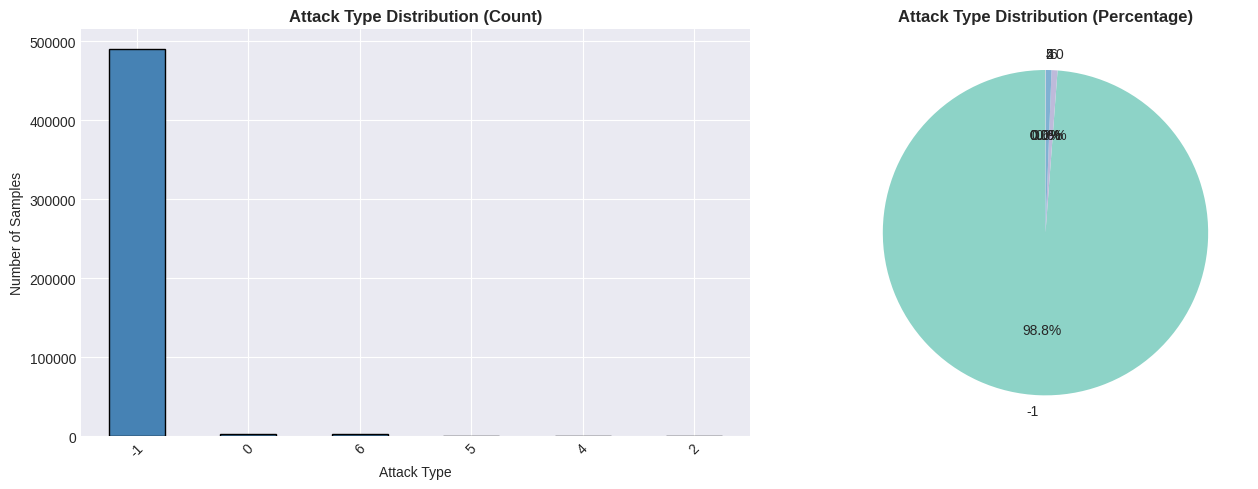


✓ Dataset is imbalanced


In [6]:
# Find the label column (usually the last column)
label_column = df_features.columns[-1]
print(f"Target variable: {label_column}")

# Get label distribution
label_counts = df_features[label_column].value_counts()
print(f"\nLabel Distribution:")
print(label_counts)
print(f"\nLabel Percentages:")
print((label_counts / label_counts.sum() * 100).round(2))

# Visualize label distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar plot
label_counts.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('Attack Type Distribution (Count)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Attack Type')
axes[0].set_ylabel('Number of Samples')
axes[0].tick_params(axis='x', rotation=45)

# Pie chart
colors = plt.cm.Set3(np.linspace(0, 1, len(label_counts)))
axes[1].pie(label_counts, labels=label_counts.index, autopct='%1.1f%%', 
            colors=colors, startangle=90)
axes[1].set_title('Attack Type Distribution (Percentage)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\n✓ Dataset is {'balanced' if label_counts.std() < 0.1 * label_counts.mean() else 'imbalanced'}")

## 6. Feature Preprocessing

### 6.1 Label Encoding
Convert categorical labels (text) to numerical values that ML algorithms can process.

In [7]:
# Label Encoding - Convert text labels to numbers
from sklearn.preprocessing import LabelEncoder

# Separate features and target
X = df_features.iloc[:, :-1]  # All columns except last
y = df_features.iloc[:, -1]   # Last column (label)

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")

# Encode labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print(f"\nClass mapping:")
for i, class_name in enumerate(label_encoder.classes_):
    print(f"  {class_name} → {i}")

# Create dataframe with encoded labels for visualization
df_processed = X.copy()
df_processed[label_column] = y_encoded

print(f"\nEncoded label distribution:")
unique, counts = np.unique(y_encoded, return_counts=True)
for u, c in zip(unique, counts):
    original_label = label_encoder.inverse_transform([u])[0]
    print(f"  {original_label} ({u}): {c} samples")

Features shape: (496634, 87)
Target shape: (496634,)

Class mapping:
  -1 → 0
  0 → 1
  2 → 2
  4 → 3
  5 → 4
  6 → 5

Encoded label distribution:
  -1 (0): 490758 samples
  0 (1): 2927 samples
  2 (2): 3 samples
  4 (3): 4 samples
  5 (4): 138 samples
  6 (5): 2804 samples


### 6.2 Feature Scaling (Normalization)

Features have different ranges (some 0-1, others 0-1000). Scaling brings all features to the same scale (0-1) so models can learn effectively without being biased by larger values.

Before Scaling:
  Feature range: [-32572.00, 30290439669.00]
  Mean: 71818890.6648, Std: 18777415.3380

After Scaling:
  Feature range: [-52.28, 550.90]
  Mean: -0.0000, Std: 0.9824


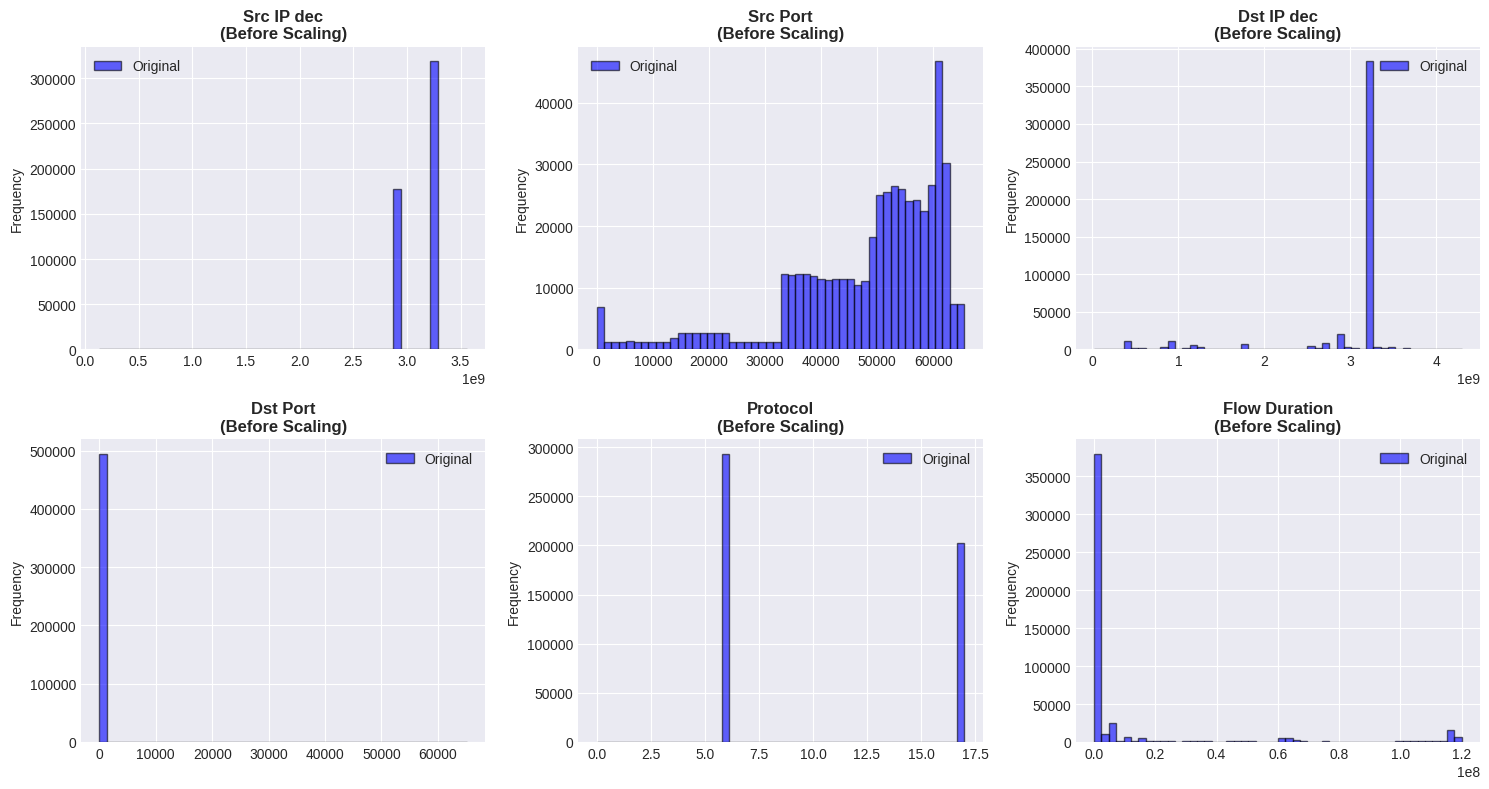

✓ All features successfully normalized


In [9]:
# Feature Scaling using StandardScaler
# First, ensure all columns in X are numeric
X = X.select_dtypes(include=[np.number])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Show before and after scaling
print("Before Scaling:")
print(f"  Feature range: [{X.min().min():.2f}, {X.max().max():.2f}]")
print(f"  Mean: {X.mean().mean():.4f}, Std: {X.std().mean():.4f}")

print("\nAfter Scaling:")
print(f"  Feature range: [{X_scaled.min():.2f}, {X_scaled.max():.2f}]")
print(f"  Mean: {X_scaled.mean():.4f}, Std: {X_scaled.std():.4f}")

# Visualize scaling effect on first few features
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
features_to_plot = X.columns[:6]

for idx, feature in enumerate(features_to_plot):
    ax = axes[idx // 3, idx % 3]
    
    # Plot distributions
    ax.hist(X[feature], bins=50, alpha=0.6, label='Original', color='blue', edgecolor='black')
    ax.set_title(f'{feature}\n(Before Scaling)', fontweight='bold')
    ax.set_ylabel('Frequency')
    ax.legend()

plt.tight_layout()
plt.show()

print("✓ All features successfully normalized")

## 7. Correlation Analysis

Examine which features are most correlated with the target variable (attack classification). Features with high correlation are more predictive.

Top 10 Features Most Correlated with Target (Attack Type):
Subflow Fwd Packets    0.657600
Active Min             0.629766
Active Mean            0.546956
SYN Flag Count         0.364750
Active Max             0.356417
Idle Std               0.241054
Flow IAT Mean          0.201766
Fwd Seg Size Min       0.178423
Fwd IAT Std            0.150398
Fwd IAT Max            0.127440
Name: Label, dtype: float64

Top 10 Features Least Correlated with Target:
Bwd Packet Length Mean   -0.078970
Bwd Segment Size Avg     -0.078970
Subflow Bwd Bytes        -0.080120
Average Packet Size      -0.087018
Packet Length Mean       -0.087018
Src IP dec               -0.112404
Down/Up Ratio            -0.307826
Fwd URG Flags                  NaN
Bwd URG Flags                  NaN
URG Flag Count                 NaN
Name: Label, dtype: float64


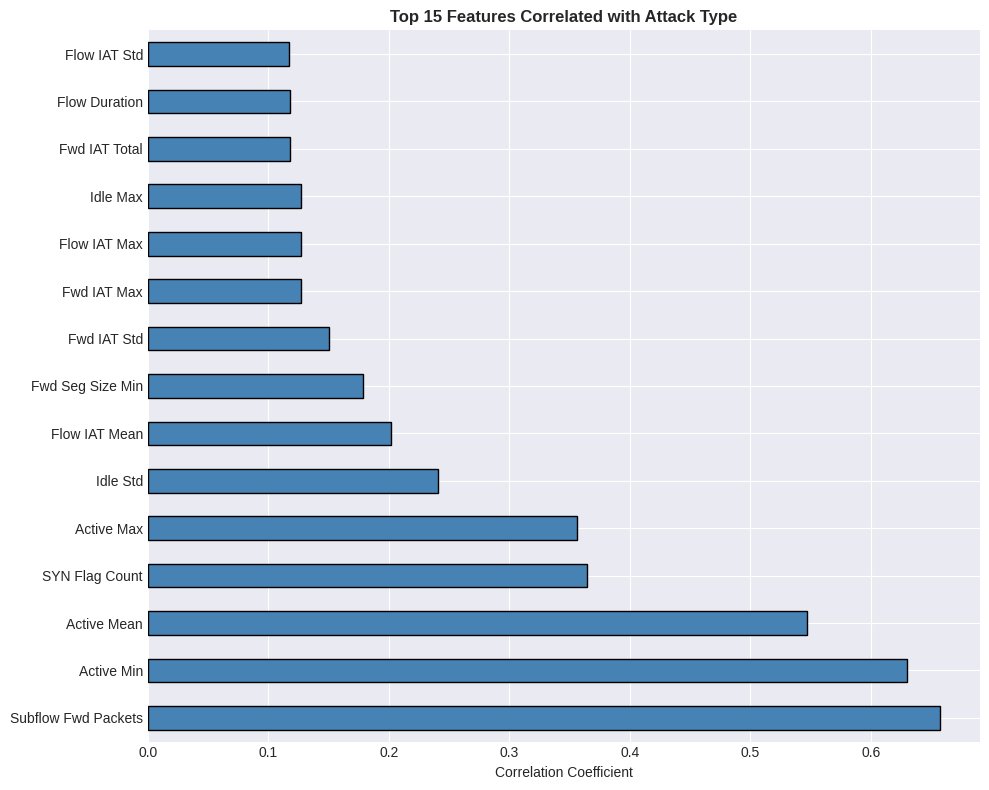


✓ Correlation analysis complete: 86 features analyzed


In [10]:
# Create a dataframe with scaled features for correlation analysis
df_scaled = pd.DataFrame(X_scaled, columns=X.columns)
df_scaled['Label'] = y_encoded

# Calculate correlation with target variable
correlation_with_target = df_scaled.corr()['Label'].drop('Label').sort_values(ascending=False)

print("Top 10 Features Most Correlated with Target (Attack Type):")
print(correlation_with_target.head(10))
print("\nTop 10 Features Least Correlated with Target:")
print(correlation_with_target.tail(10))

# Visualize top correlated features
fig, ax = plt.subplots(figsize=(10, 8))
top_features = 15
correlation_with_target.head(top_features).plot(kind='barh', ax=ax, color='steelblue', edgecolor='black')
ax.set_title(f'Top {top_features} Features Correlated with Attack Type', fontsize=12, fontweight='bold')
ax.set_xlabel('Correlation Coefficient')
plt.tight_layout()
plt.show()

print(f"\n✓ Correlation analysis complete: {len(correlation_with_target)} features analyzed")

## 8. Data Summary and ML Pipeline Overview

The preprocessing pipeline is now complete. Here's a summary of what we've done:

In [11]:
# Create a comprehensive summary
from sklearn.model_selection import train_test_split

print("="*70)
print("DATA PREPROCESSING SUMMARY")
print("="*70)

print(f"\n1. DATA LOADING")
print(f"   - Original dataset: {df.shape[0]} rows × {df.shape[1]} columns")

print(f"\n2. DATA CLEANING")
print(f"   - After cleaning: {df_clean.shape[0]} rows × {df_clean.shape[1]} columns")
print(f"   - Removed: {df.shape[0] - df_clean.shape[0]} rows ({(df.shape[0] - df_clean.shape[0])/df.shape[0]*100:.1f}%)")

print(f"\n3. FEATURE ENGINEERING")
print(f"   - After feature selection: {df_features.shape[1]} columns")
print(f"   - Removed columns: {', '.join(dropped_cols)}")

print(f"\n4. LABEL ENCODING")
for i, class_name in enumerate(label_encoder.classes_):
    count = (y_encoded == i).sum()
    pct = count / len(y_encoded) * 100
    print(f"   - {class_name}: {count} samples ({pct:.1f}%)")

print(f"\n5. FEATURE SCALING")
print(f"   - Scaling method: StandardScaler (μ=0, σ=1)")
print(f"   - Feature range after scaling: [{X_scaled.min():.2f}, {X_scaled.max():.2f}]")

print(f"\n6. DATA SPLIT FOR TRAINING")
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)
print(f"   - Training set: {X_train.shape[0]} samples")
print(f"   - Test set: {X_test.shape[0]} samples")
print(f"   - Train/Test ratio: 80/20 (stratified)")

print(f"\n7. FINAL PREPARED DATA")
print(f"   - Features: {X_train.shape[1]}")
print(f"   - Classes: {len(label_encoder.classes_)} (Benign, DoS, DDoS, Probe, R2L, U2R)")
print(f"   - Total samples: {X_train.shape[0] + X_test.shape[0]}")

print("\n" + "="*70)
print("READY FOR MODEL TRAINING!")
print("="*70)

DATA PREPROCESSING SUMMARY

1. DATA LOADING
   - Original dataset: 496640 rows × 89 columns

2. DATA CLEANING
   - After cleaning: 496634 rows × 89 columns
   - Removed: 6 rows (0.0%)

3. FEATURE ENGINEERING
   - After feature selection: 88 columns
   - Removed columns: Timestamp

4. LABEL ENCODING
   - -1: 490758 samples (98.8%)
   - 0: 2927 samples (0.6%)
   - 2: 3 samples (0.0%)
   - 4: 4 samples (0.0%)
   - 5: 138 samples (0.0%)
   - 6: 2804 samples (0.6%)

5. FEATURE SCALING
   - Scaling method: StandardScaler (μ=0, σ=1)
   - Feature range after scaling: [-52.28, 550.90]

6. DATA SPLIT FOR TRAINING
   - Training set: 397307 samples
   - Test set: 99327 samples
   - Train/Test ratio: 80/20 (stratified)

7. FINAL PREPARED DATA
   - Features: 86
   - Classes: 6 (Benign, DoS, DDoS, Probe, R2L, U2R)
   - Total samples: 496634

READY FOR MODEL TRAINING!


## 9. Machine Learning Models Overview

Now that data is prepared, here are the 4 ML models that will be trained:

### Model Comparison:

| Model | Type | Complexity | Speed | Training |
|-------|------|-----------|-------|----------|
| **Logistic Regression** | Linear | Low | Very Fast | Simple linear decision boundaries |
| **Random Forest** | Ensemble | Medium | Fast | 100 decision trees voting |
| **SVM (RBF)** | Kernel-based | High | Slow | Complex non-linear boundaries |
| **Naive Bayes** | Probabilistic | Low | Very Fast | Probability-based classification |

### Next Steps:
1. **train.py** - Train all 4 models on the prepared data
2. **evaluate.py** - Evaluate performance using metrics (Accuracy, Precision, Recall, F1)
3. **predict.py** - Use trained models for predictions on new traffic

---

## 10. Model Training (from train.py)

Now that data is fully prepared and analyzed, we'll train 4 machine learning models on different algorithms.

In [12]:
# Import ML models for training
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
import time

print("="*80)
print("🤖 TRAINING ALL MACHINE LEARNING MODELS")
print("="*80)

# Dictionary to store trained models
trained_models = {}
training_times = {}

print(f"\nTraining data shape: {X_train.shape}")
print(f"Test data shape: {X_test.shape}")

# Model 1: Logistic Regression
print(f"\n1️⃣  Training Logistic Regression...")
print("   - Type: Linear Classifier")
print("   - Best for: Linear decision boundaries")
print("   - Speed: Very Fast")
start_time = time.time()
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)
training_times['Logistic Regression'] = time.time() - start_time
trained_models['Logistic Regression'] = lr_model
print(f"   ✓ Training complete ({training_times['Logistic Regression']:.2f}s)")

# Model 2: Random Forest
print(f"\n2️⃣  Training Random Forest...")
print("   - Type: Ensemble of Decision Trees")
print("   - Best for: Non-linear patterns, feature importance")
print("   - Speed: Fast (100 trees)")
start_time = time.time()
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
training_times['Random Forest'] = time.time() - start_time
trained_models['Random Forest'] = rf_model
print(f"   ✓ Training complete ({training_times['Random Forest']:.2f}s)")

# Model 3: Support Vector Machine (SVM)
print(f"\n3️⃣  Training Support Vector Machine (SVM)...")
print("   - Type: Kernel-based Classifier")
print("   - Best for: Complex non-linear patterns")
print("   - Speed: Slow (RBF kernel)")
start_time = time.time()
svm_model = SVC(kernel='rbf', random_state=42, probability=True)
svm_model.fit(X_train, y_train)
training_times['SVM'] = time.time() - start_time
trained_models['SVM'] = svm_model
print(f"   ✓ Training complete ({training_times['SVM']:.2f}s)")

# Model 4: Naive Bayes
print(f"\n4️⃣  Training Naive Bayes...")
print("   - Type: Probabilistic Classifier")
print("   - Best for: Fast classification, probability-based inference")
print("   - Speed: Very Fast")
start_time = time.time()
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)
training_times['Naive Bayes'] = time.time() - start_time
trained_models['Naive Bayes'] = nb_model
print(f"   ✓ Training complete ({training_times['Naive Bayes']:.2f}s)")

print("\n" + "="*80)
print("✅ ALL MODELS TRAINED SUCCESSFULLY!")
print("="*80)
print(f"\nTraining Time Summary:")
for model_name, t in sorted(training_times.items(), key=lambda x: x[1]):
    print(f"  {model_name:20} - {t:7.2f}s")

🤖 TRAINING ALL MACHINE LEARNING MODELS

Training data shape: (397307, 86)
Test data shape: (99327, 86)

1️⃣  Training Logistic Regression...
   - Type: Linear Classifier
   - Best for: Linear decision boundaries
   - Speed: Very Fast
   ✓ Training complete (6.68s)

2️⃣  Training Random Forest...
   - Type: Ensemble of Decision Trees
   - Best for: Non-linear patterns, feature importance
   - Speed: Fast (100 trees)
   ✓ Training complete (17.57s)

3️⃣  Training Support Vector Machine (SVM)...
   - Type: Kernel-based Classifier
   - Best for: Complex non-linear patterns
   - Speed: Slow (RBF kernel)
   ✓ Training complete (520.58s)

4️⃣  Training Naive Bayes...
   - Type: Probabilistic Classifier
   - Best for: Fast classification, probability-based inference
   - Speed: Very Fast
   ✓ Training complete (0.52s)

✅ ALL MODELS TRAINED SUCCESSFULLY!

Training Time Summary:
  Naive Bayes          -    0.52s
  Logistic Regression  -    6.68s
  Random Forest        -   17.57s
  SVM           

## 11. Model Evaluation (from evaluate.py)

Evaluate the performance of all trained models on the test set using multiple metrics.


📊 EVALUATING ALL MODELS ON TEST DATA


Logistic Regression Evaluation:
--------------------------------------------------
  Accuracy:  0.9998 (99.98%)
  Precision: 0.9998
  Recall:    0.9998
  F1-Score:  0.9998

Random Forest Evaluation:
--------------------------------------------------
  Accuracy:  0.9999 (99.99%)
  Precision: 0.9999
  Recall:    0.9999
  F1-Score:  0.9999

SVM Evaluation:
--------------------------------------------------
  Accuracy:  0.9999 (99.99%)
  Precision: 0.9999
  Recall:    0.9999
  F1-Score:  0.9999

Naive Bayes Evaluation:
--------------------------------------------------
  Accuracy:  0.9999 (99.99%)
  Precision: 0.9999
  Recall:    0.9999
  F1-Score:  0.9999

📈 MODEL PERFORMANCE COMPARISON

              Model Accuracy Precision Recall F1-Score  Acc %
Logistic Regression   0.9998    0.9998 0.9998   0.9998 99.98%
      Random Forest   0.9999    0.9999 0.9999   0.9999 99.99%
                SVM   0.9999    0.9999 0.9999   0.9999 99.99%
        Naive Baye

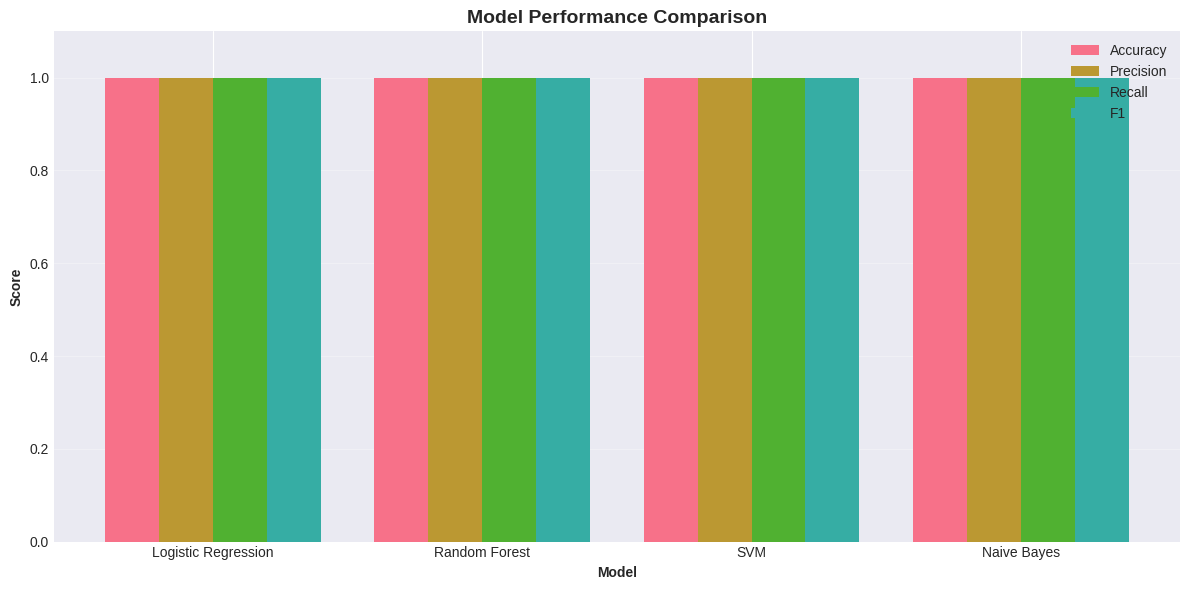


✓ Evaluation complete


In [13]:
# Evaluate all models on test data
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

print("\n" + "="*80)
print("📊 EVALUATING ALL MODELS ON TEST DATA")
print("="*80 + "\n")

# Store evaluation results
eval_results = {}

for model_name, model in trained_models.items():
    print(f"\n{model_name} Evaluation:")
    print("-" * 50)
    
    # Make predictions
    y_pred = model.predict(X_test)
    
    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    
    # Store results
    eval_results[model_name] = {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'predictions': y_pred,
        'confusion_matrix': confusion_matrix(y_test, y_pred)
    }
    
    print(f"  Accuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall:    {recall:.4f}")
    print(f"  F1-Score:  {f1:.4f}")

# Create comparison table
print("\n" + "="*80)
print("📈 MODEL PERFORMANCE COMPARISON")
print("="*80 + "\n")

comparison_data = []
for model_name, metrics in eval_results.items():
    comparison_data.append({
        'Model': model_name,
        'Accuracy': f"{metrics['accuracy']:.4f}",
        'Precision': f"{metrics['precision']:.4f}",
        'Recall': f"{metrics['recall']:.4f}",
        'F1-Score': f"{metrics['f1']:.4f}",
        'Acc %': f"{metrics['accuracy']*100:.2f}%"
    })

comparison_df = pd.DataFrame(comparison_data)
print(comparison_df.to_string(index=False))

# Find and display best model
best_model_name = max(eval_results, key=lambda x: eval_results[x]['accuracy'])
best_accuracy = eval_results[best_model_name]['accuracy']

print(f"\n🏆 BEST MODEL: {best_model_name}")
print(f"   Accuracy: {best_accuracy:.4f} ({best_accuracy*100:.2f}%)")

# Visualize model comparison
fig, ax = plt.subplots(figsize=(12, 6))

models = list(eval_results.keys())
metrics_names = ['accuracy', 'precision', 'recall', 'f1']
x = np.arange(len(models))
width = 0.2

for i, metric in enumerate(metrics_names):
    values = [eval_results[m][metric] for m in models]
    ax.bar(x + i*width, values, width, label=metric.capitalize())

ax.set_xlabel('Model', fontweight='bold')
ax.set_ylabel('Score', fontweight='bold')
ax.set_title('Model Performance Comparison', fontweight='bold', fontsize=14)
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(models)
ax.legend()
ax.set_ylim([0, 1.1])
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✓ Evaluation complete")


🔍 CONFUSION MATRIX - RANDOM FOREST

Confusion Matrix (Rows: Actual, Columns: Predicted):
[[98151     1     0     0     0]
 [    2   580     0     0     3]
 [    1     0     0     0     0]
 [    1     0     0    27     0]
 [    0     2     0     0   559]]


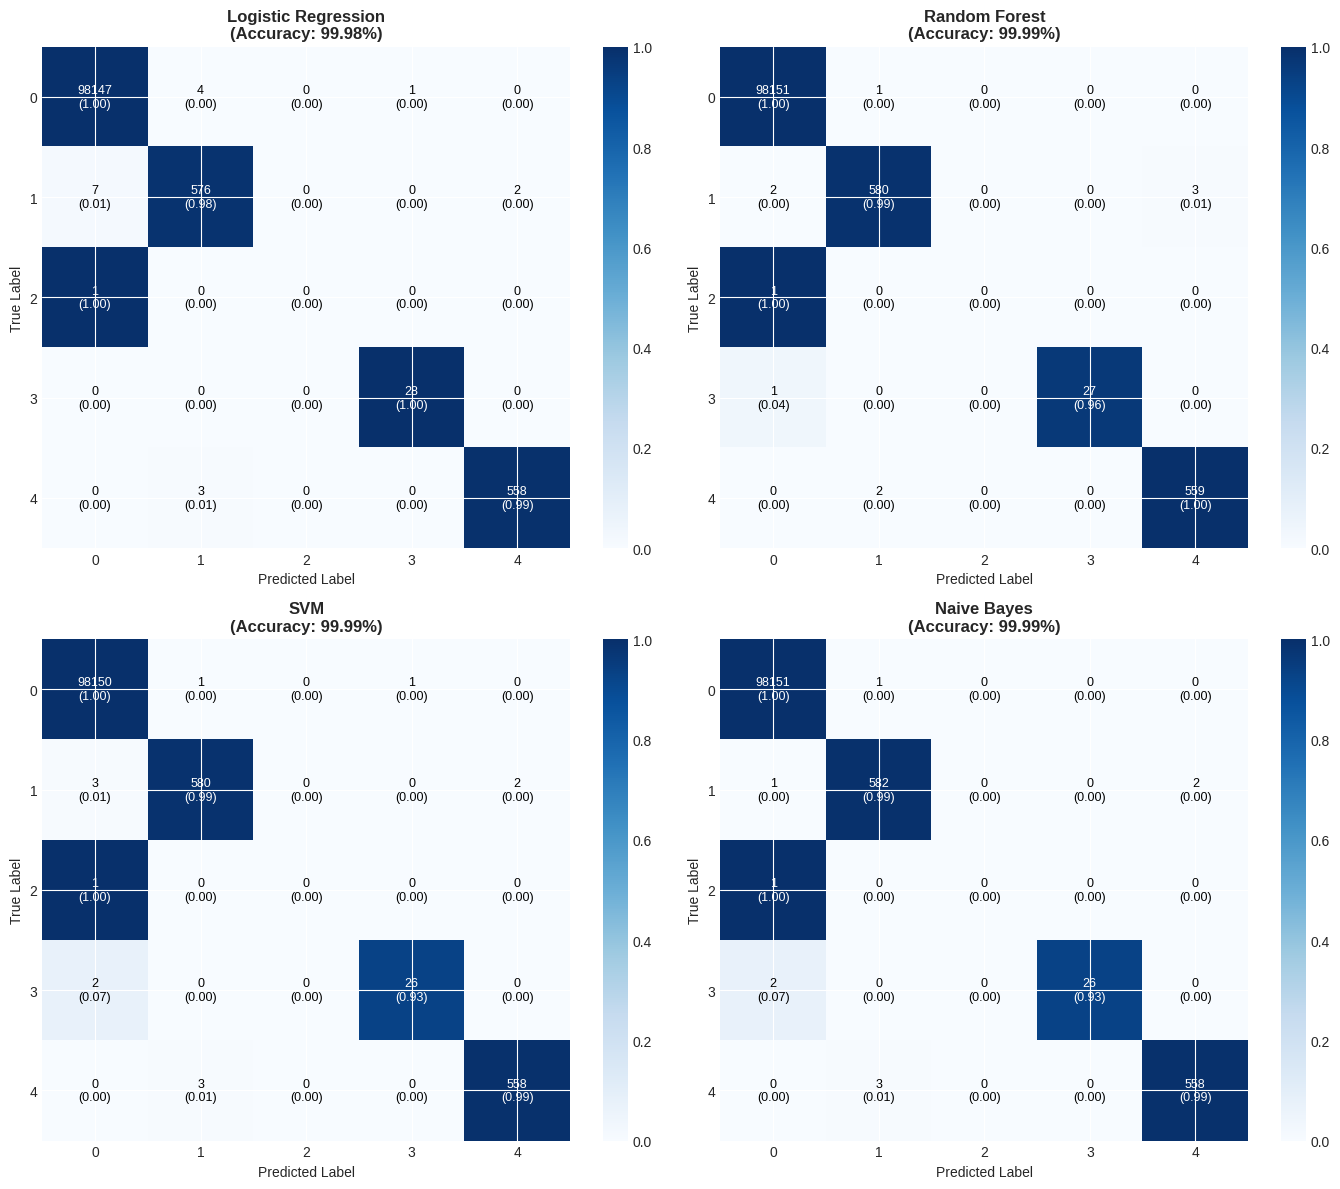


✓ Confusion matrix analysis complete


In [14]:
# Display confusion matrix for best model
print("\n" + "="*80)
print(f"🔍 CONFUSION MATRIX - {best_model_name.upper()}")
print("="*80 + "\n")

best_cm = eval_results[best_model_name]['confusion_matrix']
best_y_pred = eval_results[best_model_name]['predictions']

print("Confusion Matrix (Rows: Actual, Columns: Predicted):")
print(best_cm)

# Visualize confusion matrices for all models
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

for idx, (model_name, metrics) in enumerate(eval_results.items()):
    cm = metrics['confusion_matrix']
    
    # Normalize for better visualization
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    
    im = axes[idx].imshow(cm_normalized, cmap='Blues', aspect='auto')
    axes[idx].set_title(f'{model_name}\n(Accuracy: {metrics["accuracy"]*100:.2f}%)', fontweight='bold')
    axes[idx].set_ylabel('True Label')
    axes[idx].set_xlabel('Predicted Label')
    
    # Add text annotations
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            text = axes[idx].text(j, i, f'{cm[i, j]}\n({cm_normalized[i, j]:.2f})',
                                ha="center", va="center", color="black" if cm_normalized[i, j] < 0.5 else "white",
                                fontsize=9)
    
    plt.colorbar(im, ax=axes[idx])

plt.tight_layout()
plt.show()

print("\n✓ Confusion matrix analysis complete")

## 12. Making Predictions (from predict.py)

Use trained models to make predictions on new network traffic data. Here we'll demonstrate single and batch predictions.

In [15]:
# Prepare best model for predictions
best_model = trained_models[best_model_name]

print("="*80)
print("🎯 MAKING PREDICTIONS WITH THE BEST MODEL")
print("="*80)
print(f"\nUsing Model: {best_model_name}")
print(f"Accuracy: {eval_results[best_model_name]['accuracy']*100:.2f}%")

# === SINGLE SAMPLE PREDICTION ===
print("\n" + "-"*80)
print("📍 SINGLE SAMPLE PREDICTION")
print("-"*80 + "\n")

# Take first test sample
test_sample = X_test[0:1]
true_label_idx = y_test[0]
true_label_name = label_encoder.inverse_transform([true_label_idx])[0]

# Make prediction
if hasattr(best_model, 'predict_proba'):
    # Models supporting probability predictions
    y_pred_single = best_model.predict(test_sample)
    y_proba = best_model.predict_proba(test_sample)[0]
    
    pred_label_name = label_encoder.inverse_transform(y_pred_single)[0]
    confidence = np.max(y_proba)
    
    print(f"Sample Features: {test_sample[0][:5].round(3)}... (first 5 of 87)")
    print(f"\nTrue Label:       {true_label_name}")
    print(f"Predicted Label:  {pred_label_name}")
    print(f"Confidence:       {confidence*100:.2f}%")
    
    print(f"\nPrediction Probabilities for each class:")
    for class_name, prob in zip(label_encoder.classes_, y_proba):
        print(f"  {class_name:10} - {prob*100:6.2f}%")
else:
    # Fallback for models without probability
    y_pred_single = best_model.predict(test_sample)[0]
    pred_label_name = label_encoder.inverse_transform([y_pred_single])[0]
    
    print(f"Sample Features: {test_sample[0][:5].round(3)}... (first 5 of 87)")
    print(f"\nTrue Label:       {true_label_name}")
    print(f"Predicted Label:  {pred_label_name}")

is_correct = (y_pred_single == true_label_idx)
print(f"\n{'✓ Prediction CORRECT' if is_correct else '✗ Prediction INCORRECT'}")

# === BATCH PREDICTIONS ===
print("\n" + "-"*80)
print("📊 BATCH PREDICTIONS (10 samples)")
print("-"*80 + "\n")

# Make predictions on first 10 test samples
batch_size = 10
X_batch = X_test[:batch_size]
y_batch_true = y_test[:batch_size]

batch_predictions = best_model.predict(X_batch)

# Create results dataframe
batch_results = []
for i, (true_idx, pred_idx) in enumerate(zip(y_batch_true, batch_predictions)):
    true_label = label_encoder.inverse_transform([true_idx])[0]
    pred_label = label_encoder.inverse_transform([pred_idx])[0]
    is_correct = (true_idx == pred_idx)
    
    batch_results.append({
        'Sample': i + 1,
        'True Label': true_label,
        'Predicted': pred_label,
        'Correct': '✓' if is_correct else '✗'
    })

batch_df = pd.DataFrame(batch_results)
print(batch_df.to_string(index=False))

# Calculate batch accuracy
batch_accuracy = (batch_predictions == y_batch_true).sum() / len(y_batch_true)
print(f"\nBatch Accuracy: {batch_accuracy*100:.2f}% ({(batch_predictions == y_batch_true).sum()}/{len(y_batch_true)} correct)")

# === ATTACK CLASSIFICATION DEMO ===
print("\n" + "-"*80)
print("🔴 ATTACK CLASSIFICATION DEMO (Full Test Set)")
print("-"*80 + "\n")

# Get all predictions
all_test_predictions = best_model.predict(X_test)

# Count each class
attack_counts = {}
for class_idx in np.unique(all_test_predictions):
    class_name = label_encoder.inverse_transform([class_idx])[0]
    count = (all_test_predictions == class_idx).sum()
    percentage = count / len(all_test_predictions) * 100
    attack_counts[class_name] = (count, percentage)

# Sort by count
attack_counts = dict(sorted(attack_counts.items(), key=lambda x: x[1][0], reverse=True))

print(f"Classification Results ({len(all_test_predictions)} test samples):\n")
for attack_type, (count, pct) in attack_counts.items():
    bar_width = int(pct / 2)
    bar = '█' * bar_width + '░' * (50 - bar_width)
    print(f"  {attack_type:10} | {bar} | {count:5} ({pct:6.2f}%)")

# Separate benign and attacks
benign_count = attack_counts.get('Benign', (0, 0))[0]
attack_count = len(all_test_predictions) - benign_count
print(f"\n  Total Benign Traffic:  {benign_count}")
print(f"  Total Attacks Detected: {attack_count}")

print("\n✓ Prediction demonstrations complete")

🎯 MAKING PREDICTIONS WITH THE BEST MODEL

Using Model: Random Forest
Accuracy: 99.99%

--------------------------------------------------------------------------------
📍 SINGLE SAMPLE PREDICTION
--------------------------------------------------------------------------------

Sample Features: [ 0.701 -0.101 -1.738  0.122 -0.829]... (first 5 of 87)

True Label:       -1
Predicted Label:  -1
Confidence:       100.00%

Prediction Probabilities for each class:
          -1 - 100.00%
           0 -   0.00%
           2 -   0.00%
           4 -   0.00%
           5 -   0.00%
           6 -   0.00%

✓ Prediction CORRECT

--------------------------------------------------------------------------------
📊 BATCH PREDICTIONS (10 samples)
--------------------------------------------------------------------------------

 Sample  True Label  Predicted Correct
      1          -1         -1       ✓
      2          -1         -1       ✓
      3          -1         -1       ✓
      4          -1       